# DARTS: Chronos

In [ ]:
#Chronos isn’t part of Darts—it's a family of pretrained time series forecasting models (based on T5 transformer architectures) designed by Amazon that excels at zero-shot forecasting and can be fine-tuned if needed

In [ ]:
#Below is a code template using AutoGluon-TimeSeries, which provides easy access to Chronos models. This will help you forecast our dataset in a similar manner to how we've used Darts, but leveraging Chronos functionalities.

In [ ]:
# Chronos (including Chronos-Bolt) is pretrained on univariate time series.

# In AutoGluon-TimeSeries, when you melt our dataframe into long format and set item_id to "x1", "x2", "x3", the predictor actually treats them as three separate univariate series.

# That means:

# It does not learn cross-series dependencies (like TFT or N-HiTS in Darts do).

# It simply runs the Chronos model independently for each component.

In [ ]:
# Chronos and regressors

# Chronos (and Chronos-Bolt) are pretrained sequence-to-sequence Transformer models, trained only on past values of the target series.

# They are univariate forecasters:

# No regressors (a.k.a. covariates in Darts, exogenous variables in stats) are used.

# Input = history of the target.

# Output = forecasted future values.

In [ ]:
# Why Chronos is Generative AI

# Architecture

# Chronos uses Transformer-based sequence-to-sequence models (like T5 in NLP).

# These are the same architectures behind large language models (LLMs).

# Training Objective

# Just like LLMs learn to generate the next word in a sequence, Chronos is trained to generate the next value(s) in a time series.

# It learns from massive collections of time series data → this is pretraining, a hallmark of generative AI.

# Zero-Shot & Few-Shot Forecasting

# Chronos can forecast on unseen series without fine-tuning (zero-shot) or with minimal adaptation (few-shot).

# This parallels how GPT models can answer new prompts without task-specific training.

# Probabilistic Output

# Chronos generates multiple possible futures (sampled trajectories, quantiles).

# This is generative behavior — it’s not just regressing one number, but sampling plausible sequences.

In [ ]:
# Chronos in the Generative AI Landscape

# LLMs: generate text.

# Diffusion Models: generate images/audio/video.

# Chronos: generates time series forecasts (numeric sequences).

# So Chronos = a specialized generative AI model for structured numeric data.

In [ ]:
# Practical Implication

# When you use Chronos:

# You’re not fitting a small regression or ARIMA.

# You’re leveraging a pretrained generative model that has already learned broad “time series priors” from huge datasets.

# That’s why it works in zero-shot mode — it has general knowledge of how time series behave, like seasonality, trends, noise patterns.

In [ ]:
#!pip install autogluon==1.1.1 numpy==1.24.4  scikit-learn==1.3.2 matplotlib==3.7.1 pandas==2.1.4


ERROR: Ignored the following yanked versions: 0.0.2, 0.0.3, 0.0.4, 0.0.5, 0.0.6, 0.0.7, 0.0.8, 0.0.9, 0.0.10, 0.0.11, 0.0.12, 0.0.13, 0.0.14, 0.0.15
ERROR: Ignored the following versions that require a different python version: 0.1.0 Requires-Python >=3.6, <3.9; 0.1.0b20210207 Requires-Python >=3.6, <3.8; 0.1.0b20210208 Requires-Python >=3.6, <3.8; 0.1.0b20210209 Requires-Python >=3.6, <3.8; 0.1.0b20210210 Requires-Python >=3.6, <3.8; 0.1.0b20210211 Requires-Python >=3.6, <3.8; 0.1.0b20210212 Requires-Python >=3.6, <3.8; 0.1.0b20210213 Requires-Python >=3.6, <3.8; 0.1.0b20210214 Requires-Python >=3.6, <3.8; 0.1.0b20210215 Requires-Python >=3.6, <3.8; 0.1.0b20210216 Requires-Python >=3.6, <3.8; 0.1.0b20210217 Requires-Python >=3.6, <3.8; 0.1.0b20210218 Requires-Python >=3.6, <3.8; 0.1.0b20210219 Requires-Python >=3.6, <3.8; 0.1.0b20210220 Requires-Python >=3.6, <3.8; 0.1.0b20210221 Requires-Python >=3.6, <3.8; 0.1.0b20210222 Requires-Python >=3.6, <3.8; 0.1.0b20210223 Requires-Python >=

In [ ]:
pip install -U torch torchaudio --no-cache-dir

In [ ]:
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 19.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━

In [ ]:
import autogluon

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from autogluon.timeseries import TimeSeriesPredictor, TimeSeriesDataFrame
from autogluon.timeseries.models import WaveNetModel
import pandas as pd

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Pick your PICK3.csv from local machine
df = pd.read_csv("PICK3_239.csv")
print(df.head())

Saving PICK3_239.csv to PICK3_239 (1).csv
   time  x1  x2  x3
0   239   1   6   3
1   238   0   4   8
2   237   7   2   3
3   236   4   5   2
4   235   3   6   3


In [ ]:
print(df.columns.tolist())

['time ', 'x1', 'x2', 'x3']


In [ ]:
# import os, time
# print("Last modified:", time.ctime(os.path.getmtime("PICK3.csv")))

Last modified: Sat Sep  6 17:56:23 2025


In [ ]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

# 1. Load your data
#df = pd.read_csv(r"C:/Users/della/OneDrive/Desktop/POWER/PICK3/PICK3.csv")
df.columns = df.columns.str.strip()
# Assume df has columns: time, x1, x2, x3
# Melt into long format for Chronos
df_long = df.melt(id_vars=["time"], value_vars=["x1", "x2", "x3"],
                  var_name="item_id", value_name="target")
df_long = df_long.rename(columns={"time": "timestamp"})

print(df_long)

###print(df_long)
# 2. Convert to TimeSeriesDataFrame
data = TimeSeriesDataFrame.from_data_frame(
    df_long,
    id_column="item_id",
    timestamp_column="timestamp"
)

###print(data)

# train_data = data.head(238) ##########no!
# test_data = data.tail(1)

train_data = df_long[df_long["timestamp"] <= 238]

# Test (the last time step 239, for all x1, x2, x3)
######test_data = df_long[df_long["timestamp"] == 239]

prediction_length =1
predictor = TimeSeriesPredictor(prediction_length=prediction_length).fit(
train_data, presets="chronos_tiny"
)
# # 3. Define predictor
# predictor = TimeSeriesPredictor(
#     prediction_length=1,  # forecast 1 step (time=240)
#     target="target"
# )

# # 4. Fit Chronos model
# predictor.fit(
#     train_data=ts_df,
#     hyperparameters={"ChronosModel": {}},  # ensure Chronos is trained
#     time_limit=60
# )

# # 5. Forecast
# forecast = predictor.predict(ts_df)
# print(forecast)


Beginning AutoGluon training...
AutoGluon will save models to '/content/AutogluonModels/ag-20250912_162845'


     timestamp item_id  target
0          239      x1       1
1          238      x1       0
2          237      x1       7
3          236      x1       4
4          235      x1       3
..         ...     ...     ...
712          5      x3       7
713          4      x3       6
714          3      x3       6
715          2      x3       6
716          1      x3       7

[717 rows x 3 columns]


=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sun Mar 30 16:01:29 UTC 2025
CPU Count:          2
GPU Count:          0
Memory Avail:       10.77 GB / 12.67 GB (85.0%)
Disk Space Avail:   62.57 GB / 107.72 GB (58.1%)
Setting presets to: chronos_tiny

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'hyperparameters': {'Chronos': {'model_path': 'tiny'}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 1,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': True,
 'target': 'target',
 'verbosity': 2}

Inferred time series frequency: 'ns'
Provided train_data has 714 rows, 3 time series. Median time series length is 238 (min=238, max=238). 

Provided data contains following colu

In [ ]:
 ##3️⃣ Initialize predictor
predictor = TimeSeriesPredictor(
    target='target',         # your target column
    prediction_length=1      # we want to predict 1 step ahead
)

# 4️⃣ Fit the predictor
predictor.fit(train_data, presets="chronos_tiny")  # presets can be 'high_quality' etc.

# 5️⃣ Prepare last row as input to predict the next step (time 239)
last_known = df_long[df_long["timestamp"] == 238]  # last known timestamp

# 6️⃣ Predict time 239
forecast_239 = predictor.predict(last_known)

# forecast_239.loc['x2', 'mean']
# forecast_239.loc['x3', 'mean']


# # 7️⃣ Check predictions
# print(forecast_239)
# print(forecast_239.loc['x2', 'mean'],
# forecast_239.loc['x3', 'mean'])


Beginning AutoGluon training...
AutoGluon will save models to '/content/AutogluonModels/ag-20250912_163046'
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sun Mar 30 16:01:29 UTC 2025
CPU Count:          2
GPU Count:          0
Memory Avail:       10.26 GB / 12.67 GB (80.9%)
Disk Space Avail:   62.54 GB / 107.72 GB (58.1%)
Setting presets to: chronos_tiny

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'hyperparameters': {'Chronos': {'model_path': 'tiny'}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 1,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': True,
 'target': 'target',
 'verbosity': 2}

Inferred time series frequency: 'ns'
Provided train_data has 714 rows,

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

In [ ]:
print(forecast_239)

# forecast_239.loc['x2', 'mean']
# forecast_239.loc['x3', 'mean']

                                           mean           0.1           0.2  \
item_id timestamp                                                             
x1      1970-01-01 00:00:00.000000239  0.068915  1.396984e-08  1.396984e-08   
x2      1970-01-01 00:00:00.000000239  6.315249  3.076246e+00  3.360704e+00   
x3      1970-01-01 00:00:00.000000239  7.439883  6.838710e+00  7.436950e+00   

                                                0.3           0.4       0.5  \
item_id timestamp                                                             
x1      1970-01-01 00:00:00.000000239  1.396984e-08  1.396984e-08  0.010997   
x2      1970-01-01 00:00:00.000000239  3.524927e+00  3.753666e+00  3.973607   
x3      1970-01-01 00:00:00.000000239  7.847507e+00  7.953079e+00  7.976540   

                                            0.6       0.7       0.8       0.9  
item_id timestamp                                                              
x1      1970-01-01 00:00:00.000000239  0.027859 

In [ ]:
#forecast_239.loc['x1', 'mean']


In [ ]:
pred_x1 = forecast_239.loc['x1', 'mean'].item()
print(pred_x1)

0.06891496479511261


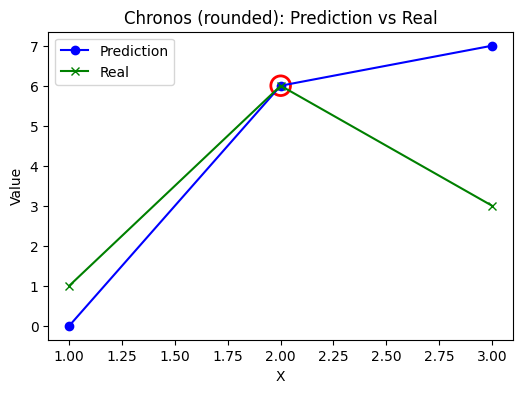

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
Y_pred =np.array([forecast_239.loc['x1', 'mean'].item(),
                 forecast_239.loc['x2', 'mean'].item(), forecast_239.loc['x3', 'mean'].item()])
#forecast.values().flatten()   # shape (3,)
Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("Chronos (rounded): Prediction vs Real")
plt.show()

# chronos_large_ensemble

#chronos_large_ensemble using the same dataset as above which builds an ensemble of seasonal naive, tree-based, and deep learning models with fast  inference.

In [ ]:
import autogluon
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from autogluon.timeseries import TimeSeriesPredictor,TimeSeriesDataFrame
import pandas as pd

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Pick your PICK3.csv from local machine
df = pd.read_csv("PICK3_239.csv")
print(df.head())

Saving PICK3_239.csv to PICK3_239.csv
   time  x1  x2  x3
0   239   1   6   3
1   238   0   4   8
2   237   7   2   3
3   236   4   5   2
4   235   3   6   3


In [ ]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

# 1. Load your data
#df = pd.read_csv(r"C:/Users/della/OneDrive/Desktop/POWER/PICK3/PICK3.csv")
df.columns = df.columns.str.strip()
# Assume df has columns: time, x1, x2, x3
# Melt into long format for Chronos
df_long = df.melt(id_vars=["time"], value_vars=["x1", "x2", "x3"],
                  var_name="item_id", value_name="target")
df_long = df_long.rename(columns={"time": "timestamp"})

print(df_long)

###print(df_long)
# 2. Convert to TimeSeriesDataFrame
data = TimeSeriesDataFrame.from_data_frame(
    df_long,
    id_column="item_id",
    timestamp_column="timestamp"
)

###print(data)

# train_data = data.head(238) ##########no!
# test_data = data.tail(1)

train_data = df_long[df_long["timestamp"] <= 238]

# Test (the last time step 239, for all x1, x2, x3)
######test_data = df_long[df_long["timestamp"] == 239]


# # 3. Define predictor
# predictor = TimeSeriesPredictor(
#     prediction_length=1,  # forecast 1 step (time=240)
#     target="target"
# )

# # 4. Fit Chronos model
# predictor.fit(
#     train_data=ts_df,
#     hyperparameters={"ChronosModel": {}},  # ensure Chronos is trained
#     time_limit=60
# )

# # 5. Forecast
# forecast = predictor.predict(ts_df)
# print(forecast)


     timestamp item_id  target
0          239      x1       1
1          238      x1       0
2          237      x1       7
3          236      x1       4
4          235      x1       3
..         ...     ...     ...
712          5      x3       7
713          4      x3       6
714          3      x3       6
715          2      x3       6
716          1      x3       7

[717 rows x 3 columns]


In [ ]:
prediction_length =1
predictor = TimeSeriesPredictor(prediction_length=prediction_length).fit(
train_data, presets="chronos_large_ensemble"
)

Beginning AutoGluon training...
AutoGluon will save models to '/content/AutogluonModels/ag-20250912_164143'
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.11
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Sun Mar 30 16:01:29 UTC 2025
CPU Count:          2
GPU Count:          1
Memory Avail:       10.66 GB / 12.67 GB (84.1%)
Disk Space Avail:   67.49 GB / 112.64 GB (59.9%)
Setting presets to: chronos_large_ensemble

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'hyperparameters': {'Chronos': {'batch_size': 8, 'model_path': 'large'},
                     'DirectTabular': {},
                     'PatchTST': {},
                     'RecursiveTabular': {},
                     'SeasonalNaive': {},
                     'TemporalFusionTransformer': {}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 1,
 'quantile_levels': [0.1, 0.2, 

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.84G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

	-0.5139       = Validation score (-WQL)
	14.48   s     = Training runtime
	42.26   s     = Validation (prediction) runtime
Training timeseries model TemporalFusionTransformer. 
	-0.3274       = Validation score (-WQL)
	96.75   s     = Training runtime
	0.02    s     = Validation (prediction) runtime
Training timeseries model PatchTST. 
	-0.3110       = Validation score (-WQL)
	25.98   s     = Training runtime
	0.02    s     = Validation (prediction) runtime
Fitting simple weighted ensemble.
	Ensemble weights: {'PatchTST': 0.7, 'TemporalFusionTransformer': 0.3}
	-0.3039       = Validation score (-WQL)
	0.59    s     = Training runtime
	0.04    s     = Validation (prediction) runtime
Training complete. Models trained: ['SeasonalNaive', 'RecursiveTabular', 'DirectTabular', 'Chronos[large]', 'TemporalFusionTransformer', 'PatchTST', 'WeightedEnsemble']
Total runtime: 194.15 s
Best model: WeightedEnsemble
Best model score: -0.3039


In [ ]:
# 5️⃣ Prepare last row as input to predict the next step (time 239)
last_known = df_long[df_long["timestamp"] == 238]  # last known timestamp

# 6️⃣ Predict time 239
forecast_239 = predictor.predict(last_known)

data with frequency 'IRREG' has been resampled to frequency 'ns'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


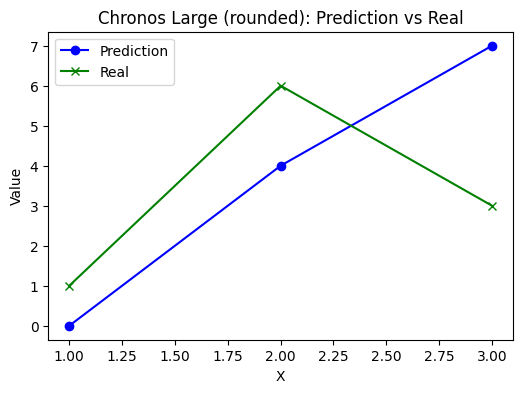

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
Y_pred =np.array([forecast_239.loc['x1', 'mean'].item(),
                 forecast_239.loc['x2', 'mean'].item(), forecast_239.loc['x3', 'mean'].item()])
#forecast.values().flatten()   # shape (3,)
Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("Chronos Large (rounded): Prediction vs Real")
plt.show()

# MOIRAI: A Time Series LLM forUniversal Forecasting

In [ ]:
#Masked EncOder-based UnIveRsAl Time Series Forecasting Transformer
# Moirai (Masked Encoder Universal Forecasting Transformer) is a foundation model for time series forecasting:

# Designed to work zero-shot across different domains, frequencies, and multivariate settings.

# Supports multivariate forecasting, so it can predict x1, x2, x3 together.

# Pretrained on massive datasets (LOTSA), enabling it to generalize well even without fine-tuning
# Hugging Face
# arXiv

In [ ]:
#MOIRAI is trained and made available in
# three sizes, MOIRAISmall, MOIRAIBase, and MOIRAILarge, with 14m,
# 91m, and 311m parameters, respectively

In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.2.2+cu121
Uninstalling torch-2.2.2+cu121:
  Successfully uninstalled torch-2.2.2+cu121
Found existing installation: torchvision 0.17.2+cu121
Uninstalling torchvision-0.17.2+cu121:
  Successfully uninstalled torchvision-0.17.2+cu121
Found existing installation: torchaudio 2.2.2+cu121
Uninstalling torchaudio-2.2.2+cu121:
  Successfully uninstalled torchaudio-2.2.2+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.2.2%2Bcu121-cp312-cp312-linux_x86_64.whl (757.2 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchvision-0.17.2%2Bcu121-cp312-cp312-linux_x86_64.whl (7.0 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchaudio-2.2.2%2Bcu121-cp312-cp312-linux_x86_64.whl (3.4 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluo

In [ ]:
#pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121


In [ ]:
!pip install uni2ts gluonts

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from einops import rearrange
from gluonts.dataset.multivariate_grouper import MultivariateGrouper

In [ ]:
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from uni2ts.eval_util.plot import plot_single, plot_next_multi
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import torch
import torchvision
print(torch.__version__, torchvision.__version__)

2.2.2+cu121 0.17.2+cu121


In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Pick your PICK3.csv from local machine
df = pd.read_csv("PICK3_239.csv")
df.columns = df.columns.str.strip()
print(df.head())

Saving PICK3.csv to PICK3 (2).csv
   time  x1  x2  x3
0   239   1   6   3
1   238   0   4   8
2   237   7   2   3
3   236   4   5   2
4   235   3   6   3


In [ ]:
# 1. Load dataset
import pandas as pd
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule
from gluonts.dataset.common import ListDataset

#df = pd.read_csv("PICK3_239.csv")
df.columns = df.columns.str.strip()

# 2. Prepare inputs and labels
inputs, labels = [], []
for col in ["x1", "x2", "x3"]:
    inp = {
        "target": df[col].to_numpy()[:238],  # context
        "start": pd.Period("1970-01-01", freq="D"),
    }
    inputs.append(inp)

    label = {
        "target": df[col].to_numpy()[238:],  # true value at time 239
        "start": pd.Period("1970-01-01", freq="D") + 238,
    }
    labels.append(label)

dataset = ListDataset(inputs, freq="D")

# 3. Load pretrained Moirai-small
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained("Salesforce/moirai-1.0-R-small"),
    prediction_length=1,        # forecast 1 step ahead (239)
    context_length=50,
    patch_size="auto",
    num_samples=1,
    target_dim=1,
    feat_dynamic_real_dim=0,
    past_feat_dynamic_real_dim=0,
)

# 4. Create predictor (✅ add batch_size)
predictor = model.create_predictor(batch_size=16)

# 5. Forecast
forecasts = list(predictor.predict(dataset))

# 6. Compare predictions vs ground truth
for i, col in enumerate(["x1", "x2", "x3"]):
    forecast_mean = float(forecasts[i].mean[0])
    true_value = int(labels[i]["target"][0])
    print(f"{col}: predicted={forecast_mean:.4f}, actual={true_value}")


x1: predicted=5.7521, actual=9
x2: predicted=6.2915, actual=7
x3: predicted=3.8269, actual=7


In [ ]:
print(float(forecasts[1].mean[0]))

6.291543960571289


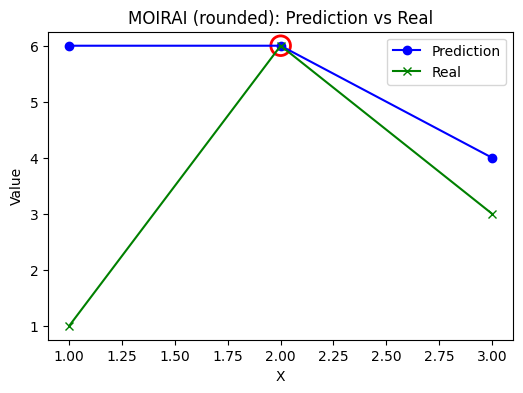

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:

#forecast.values().flatten()   # shape (3,)
###################
 Y_pred =np.array([float(forecasts[0].mean[0]),
                  float(forecasts[1].mean[0]), float(forecasts[2].mean[0])])
#forecast.values().flatten()   # shape (3,)
#############
Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("MOIRAI (rounded): Prediction vs Real")
plt.show()